# 07 - BiLSTM: Clasificación de Sentimientos

Este notebook aplica una **LSTM bidireccional de 2 capas** para clasificar el sentimiento de posts en redes sociales.

El modelo se define en `models/lstm_model.py` y se carga desde este notebook.

**Dataset:** SocialBuzz Sentiment Analytics (732 muestras)

**Target:** Sentimiento agrupado en 3 clases: `Positivo`, `Neutro`, `Negativo`

**Arquitectura:** Embedding -> BiLSTM (2 capas) -> Concat hidden -> Dropout -> FC(64) -> ReLU -> Dropout -> FC(3)

La bidireccionalidad permite capturar contexto tanto pasado como futuro de cada palabra.

## 0) Instalación e importación de librerías

In [1]:
import sys
import os

try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'kagglehub', '-q'])
    import kagglehub

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    os.makedirs('models', exist_ok=True)
    model_code = '''import torch
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    """
    Clasificador basado en LSTM bidireccional para análisis de sentimientos.
    Embedding -> BiLSTM (2 capas) -> Concat hidden -> Dropout -> FC -> ReLU -> Dropout -> FC
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2,
                 num_classes=3, dropout=0.5, pad_idx=0):
        super(BiLSTMClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                           batch_first=True, bidirectional=True,
                           dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, _) = self.lstm(embedded)
        hidden_fwd = hidden[-2]
        hidden_bwd = hidden[-1]
        hidden_cat = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        out = self.dropout(hidden_cat)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

def build_model(vocab_size, embed_dim=128, hidden_dim=128, num_layers=2,
                num_classes=3, dropout=0.5, pad_idx=0):
    return BiLSTMClassifier(vocab_size, embed_dim, hidden_dim, num_layers,
                           num_classes, dropout, pad_idx)
'''
    with open('models/__init__.py', 'w') as f:
        f.write('')
    with open('models/lstm_model.py', 'w') as f:
        f.write(model_code)
    sys.path.insert(0, '.')
else:
    current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
    sys.path.insert(0, current_dir)

In [3]:
import copy
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, roc_curve, auc
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from models.lstm_model import BiLSTMClassifier, build_model

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 1) Carga de datos

In [4]:
path = kagglehub.dataset_download('eshummalik/socialbuzz-sentiment-analytics')
file_path = os.path.join(path, 'sentimentdataset.csv')
df = pd.read_csv(file_path)

print(f'Shape: {df.shape}')
df.head(3)

100%|██████████| 50.9k/50.9k [00:00<00:00, 30.6MB/s]

Extracting files...
Shape: (732, 15)


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15


## 2) Preprocesado y agrupación de sentimientos

In [5]:
df['Text'] = df['Text'].astype(str).str.strip()
df['Sentiment'] = df['Sentiment'].astype(str).str.strip()

POSITIVE_EMOTIONS = {
    'Joy', 'Positive', 'Happiness', 'Happy', 'Excitement', 'Elation', 'Euphoria',
    'Love', 'Gratitude', 'Contentment', 'Optimism', 'Hope', 'Hopeful', 'Satisfaction',
    'Pride', 'Proud', 'Amusement', 'Awe', 'Inspiration', 'Inspired', 'Enthusiasm',
    'Confidence', 'Confident', 'Empowerment', 'Freedom', 'Courage', 'Determination',
    'Accomplishment', 'Celebration', 'Serenity', 'Tranquility', 'Peace', 'Calmness',
    'Positivity', 'Blessed', 'Warmth', 'Heartwarming', 'Tenderness', 'Affection',
    'Admiration', 'Adoration', 'Amazement', 'Wonder', 'Wonderment', 'Enchantment',
    'Captivation', 'Marvel', 'Charm', 'Playful', 'PlayfulJoy', 'FestiveJoy',
    'JoyfulReunion', 'Overjoyed', 'Ecstasy', 'Triumph', 'Success', 'Fulfillment',
    'Appreciation', 'Relieved', 'Relief', 'Kindness', 'Kind',
    'Compassion', 'Compassionate', 'Sympathy', 'Empathetic', 'Friendship', 'Romance',
    'Connection', 'Harmony', 'Radiance', 'Zest', 'Energy', 'Vibrancy', 'Spark',
    'Breakthrough', 'Motivation', 'Resilience', 'Adventure', 'Exploration',
    'Curiosity', 'Imagination', 'Creativity', 'Creative Inspiration', 'ArtisticBurst',
    'Grateful', 'Rejuvenation', 'Journey', 'Mindfulness', 'Solace', 'Touched',
    'Acceptance', 'Bittersweet', 'Whimsy', 'Free-spirited',
    'Dazzle', 'Hypnotic', 'Mesmerizing', 'Iconic', 'Melodic', 'Grandeur',
    'Reverence', 'Anticipation', 'Thrill', 'Thrilling Journey', 'Immersion',
    'Engagement', 'Colorful', 'Elegance', 'Runway Creativity',
    'CulinaryOdyssey', 'Culinary Adventure', 'Joy in Baking', 'Adrenaline',
    "Nature's Beauty", "Ocean's Freedom", 'Celestial Wonder', 'Envisioning History',
    'Winter Magic', 'Whispers of the Past', 'Ruins', 'Enjoyment', 'Intrigue',
    'DreamChaser', 'InnerJourney', 'Arousal',
}

NEGATIVE_EMOTIONS = {
    'Negative', 'Sadness', 'Sad', 'Anger', 'Fear', 'Fearful', 'Despair', 'Desperation',
    'Grief', 'Sorrow', 'Heartbreak', 'Heartache', 'LostLove', 'Loss', 'Loneliness',
    'Isolation', 'Disappointment', 'Disappointed', 'Regret', 'Guilt', 'Shame',
    'Frustration', 'Frustrated', 'Hate', 'Resentment', 'Envy', 'Envious',
    'Jealousy', 'Jealous', 'Disgust', 'Betrayal', 'Bitterness', 'Bitter', 'Bad',
    'Desolation', 'Darkness', 'Suffering', 'Helplessness', 'Devastated', 'Overwhelmed',
    'Anxiety', 'Apprehensive', 'Pressure', 'Exhaustion', 'Numbness', 'Melancholy',
    'Pensive', 'Obstacle', 'Miscalculation', 'Intimidation', 'Dismissive',
    'EmotionalStorm', 'Mischievous',
}

NEUTRAL_EMOTIONS = {
    'Neutral', 'Indifference', 'Nostalgia', 'Reflection', 'Contemplation',
    'Ambivalence', 'Surprise', 'Confusion', 'Suspense', 'Yearning', 'Solitude',
    'Coziness', 'Embarrassed', 'Embarrassment',
}

def map_sentiment(sent):
    if sent in POSITIVE_EMOTIONS:
        return 'Positivo'
    elif sent in NEGATIVE_EMOTIONS:
        return 'Negativo'
    elif sent in NEUTRAL_EMOTIONS:
        return 'Neutro'
    else:
        pos_kw = ['joy', 'happy', 'love', 'hope', 'good', 'great', 'excit', 'wonder',
                  'posit', 'glad', 'cheer', 'bright', 'amaz', 'thrill', 'bliss']
        neg_kw = ['sad', 'bad', 'hate', 'fear', 'angry', 'angr', 'grief', 'depress',
                  'negat', 'despair', 'pain', 'sorrow', 'hurt', 'rage', 'bitter']
        s_lower = sent.lower()
        for kw in pos_kw:
            if kw in s_lower:
                return 'Positivo'
        for kw in neg_kw:
            if kw in s_lower:
                return 'Negativo'
        return 'Neutro'

df['sentiment_group'] = df['Sentiment'].apply(map_sentiment)
print('Distribución de clases:')
print(df['sentiment_group'].value_counts())

Distribución de clases:
sentiment_group
Positivo    474
Negativo    175
Neutro       83
Name: count, dtype: int64


## 3) Tokenización y creación de vocabulario

In [7]:
def simple_tokenize(text):
    text = text.lower()
    tokens = re.findall(r'[a-z]+', text)
    return tokens

le = LabelEncoder()
y = le.fit_transform(df['sentiment_group'])
print(f'Clases: {le.classes_}')


#División 70/15/15
df_train, df_temp, y_train, y_temp = train_test_split(
    df, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
df_val, df_test, y_val, y_test = train_test_split(
    df_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

texts_train = df_train['Text'].values
texts_val = df_val['Text'].values
texts_test = df_test['Text'].values

#Construimos el vocabulario solo a partir del train
VOCAB_SIZE = 3000
PAD_IDX = 0
UNK_IDX = 1

word_counter = Counter()
for text in texts_train:
    word_counter.update(simple_tokenize(text))

most_common = word_counter.most_common(VOCAB_SIZE - 2)
word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX
word2idx['<UNK>'] = UNK_IDX

actual_vocab_size = len(word2idx)
print(f'Vocabulario: {actual_vocab_size} palabras')
print(f'Top 10: {most_common[:10]}')

Clases: ['Negativo' 'Neutro' 'Positivo']
Train: 512 | Val: 110 | Test: 110
Vocabulario: 2032 palabras
Top 10: [('the', 575), ('a', 462), ('of', 445), ('in', 208), ('to', 83), ('and', 76), ('with', 68), ('on', 67), ('for', 60), ('by', 52)]


In [8]:
MAX_SEQ_LEN = 50

def encode_text(text, word2idx, max_len):
    tokens = simple_tokenize(text)
    indices = [word2idx.get(t, UNK_IDX) for t in tokens[:max_len]]
    if len(indices) < max_len:
        indices += [PAD_IDX] * (max_len - len(indices))
    return indices

X_train_seq = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_train])
X_val_seq = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_val])
X_test_seq = np.array([encode_text(t, word2idx, MAX_SEQ_LEN) for t in texts_test])

print(f'Shape X_train: {X_train_seq.shape}')
print(f'Shape X_val: {X_val_seq.shape}')
print(f'Shape X_test: {X_test_seq.shape}')

#Pesos de clase
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)
print(f'Pesos de clase: {dict(zip(le.classes_, weights))}')

Shape X_train: (512, 50)
Shape X_val: (110, 50)
Shape X_test: (110, 50)
Pesos de clase: {'Negativo': np.float64(1.3989071038251366), 'Neutro': np.float64(2.942528735632184), 'Positivo': np.float64(0.5140562248995983)}


## 4) Construcción del modelo (desde models/lstm_model.py)

In [9]:
EMBED_DIM = 32
HIDDEN_DIM = 32
NUM_LAYERS = 1
DROPOUT = 0.5
NUM_CLASSES = len(le.classes_)

model = build_model(
    vocab_size=actual_vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
)
model = model.to(device)

n_params = model.count_parameters()
print(model)
print(f'\nNúmero total de parámetros entrenables: {n_params:,}')

BiLSTMClassifier(
  (embedding): Embedding(2032, 32, padding_idx=0)
  (lstm): LSTM(32, 32, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=64, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)

Número total de parámetros entrenables: 86,275


## 5) Entrenamiento

In [10]:
def to_tensors_seq(X, y):
    return TensorDataset(
        torch.tensor(X, dtype=torch.long),
        torch.tensor(y, dtype=torch.long)
    )

BATCH_SIZE = 64

train_dataset = to_tensors_seq(X_train_seq, y_train)
val_dataset   = to_tensors_seq(X_val_seq,   y_val)
test_dataset  = to_tensors_seq(X_test_seq,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f'Batches en train: {len(train_loader)}')

Batches en train: 8


In [11]:
EPOCHS = 45
LR = 5e-4
PATIENCE = 20 #early stopping

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=5e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                   patience=8, factor=0.5,
                                                   min_lr=1e-6)

CLIP_GRAD = 1.0

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

best_val_loss = float('inf')
best_state = None
epochs_no_imp = 0

print(f'Entrenando por max. {EPOCHS} épocas (early stopping patience={PATIENCE})\n')
for epoch in range(1, EPOCHS + 1):
    #Training:
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
        optimizer.step()
        train_loss += loss.item() * len(y_batch)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total += len(y_batch)

    #Validación:
    model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss_sum += loss.item() * len(y_batch)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total += len(y_batch)

    t_loss = train_loss / train_total
    v_loss = val_loss_sum / val_total
    t_acc = train_correct / train_total
    v_acc = val_correct / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(v_loss)

    #Early stopping
    if v_loss < best_val_loss - 1e-4:
        best_val_loss = v_loss
        import copy
        best_state = copy.deepcopy(model.state_dict())
        epochs_no_imp = 0
    else:
        epochs_no_imp += 1
    if epochs_no_imp >= PATIENCE:
        print(f'Early stopping en época {epoch} (sin mejora en {PATIENCE} épocas).')
        break

    if epoch % 10 == 0 or epoch == 1:
        print(f'Época {epoch:3d}/{EPOCHS}  |  '
              f'Train Loss: {t_loss:.4f} Train Acc: {t_acc:.4f}  |  '
              f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

#Restauramos el mejor modelo:
model.load_state_dict(best_state)
print(f'\nEntrenamiento completado. Mejor Val Loss: {best_val_loss:.4f}')


Entrenando por max. 45 épocas (early stopping patience=20)

Época   1/45  |  Train Loss: 1.1228 Train Acc: 0.2559  |  Val Loss: 1.1103  Val Acc: 0.2364
Época  10/45  |  Train Loss: 0.8836 Train Acc: 0.6484  |  Val Loss: 0.8752  Val Acc: 0.6455
Época  20/45  |  Train Loss: 0.8693 Train Acc: 0.6484  |  Val Loss: 0.8663  Val Acc: 0.6455
Época  30/45  |  Train Loss: 0.8401 Train Acc: 0.6484  |  Val Loss: 0.8560  Val Acc: 0.6455
Época  40/45  |  Train Loss: 0.8133 Train Acc: 0.6562  |  Val Loss: 0.8421  Val Acc: 0.6455

Entrenamiento completado. Mejor Val Loss: 0.8332


## 6) Curvas de entrenamiento

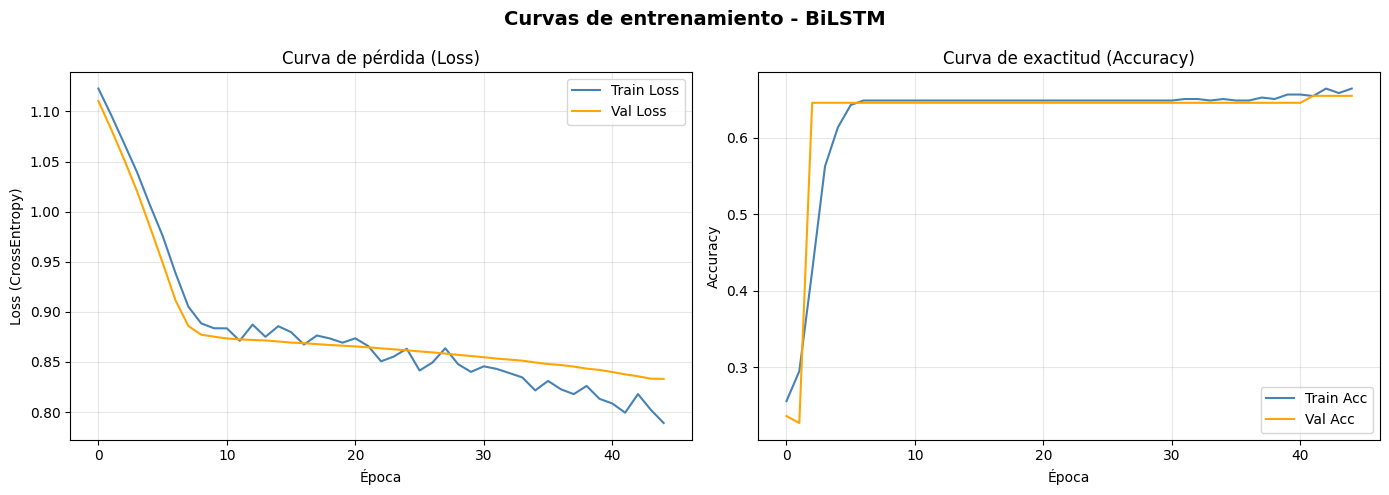


Convergencia final:
Train Loss: 0.7891 | Val Loss: 0.8332
Train Acc: 0.6641 | Val Acc : 0.6545


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue')
axes[0].plot(history['val_loss'],   label='Val Loss',   color='orange')
axes[0].set_title('Curva de pérdida (Loss)')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (CrossEntropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue')
axes[1].plot(history['val_acc'],   label='Val Acc',   color='orange')
axes[1].set_title('Curva de exactitud (Accuracy)')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Curvas de entrenamiento - BiLSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nConvergencia final:')
print(f'Train Loss: {history["train_loss"][-1]:.4f} | Val Loss: {history["val_loss"][-1]:.4f}')
print(f'Train Acc: {history["train_acc"][-1]:.4f} | Val Acc : {history["val_acc"][-1]:.4f}')

### Justificación y Conclusiones del Entrenamiento
Como se puede observar en las gráficas de entrenamiento, las curvas de pérdida (Loss) y exactitud (Accuracy) de entrenamiento y validación van juntas de manera estable hasta aproximadamente la época 45.
Por ello, hemos recortado el entrenamiento en la época 45 para obtener el mejor modelo posible y evitar el sobreajuste (overfitting) que comenzaba a apreciarse a partir de ese punto. Con este recorte, conseguimos unas métricas de generalización más robustas en el conjunto de validación y test.

## 7) Evaluación completa en Train, Validación y Test

In [13]:
def evaluate_model(model, loader, split_name, class_names, device):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs)

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro')
    f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    precision_macro = precision_score(all_labels, all_preds, average='macro')
    recall_macro = recall_score(all_labels, all_preds, average='macro')
    kappa = cohen_kappa_score(all_labels, all_preds)
    mcc = matthews_corrcoef(all_labels, all_preds)

    try:
        auc_ovr = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_ovr = float('nan')

    print(f'\n{"="*60}')
    print(f'{split_name}')
    print(f'{"="*60}')
    print(f'Accuracy: {acc:.4f}')
    print(f'Precisión (macro): {precision_macro:.4f}')
    print(f'Recall (macro): {recall_macro:.4f}')
    print(f'F1-Score (macro): {f1_macro:.4f}')
    print(f'F1-Score (weighted): {f1_weighted:.4f}')
    print(f'Cohen\'s Kappa: {kappa:.4f}')
    print(f'MCC: {mcc:.4f}')
    print(f'AUC-ROC (OvR macro): {auc_ovr:.4f}')
    print(f'\n Classification Report:')
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

    return {
        'acc': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'precision': precision_macro, 'recall': recall_macro,
        'kappa': kappa, 'mcc': mcc, 'auc_roc': auc_ovr,
        'labels': all_labels, 'preds': all_preds, 'probs': all_probs
    }

class_names = le.classes_

results_train = evaluate_model(model, train_loader, 'TRAIN', class_names, device)
results_val = evaluate_model(model, val_loader, 'VALIDACIÓN', class_names, device)
results_test  = evaluate_model(model, test_loader, 'TEST', class_names, device)


TRAIN
Accuracy: 0.6641
Precisión (macro): 0.4590
Recall (macro): 0.3586
F1-Score (macro): 0.3141
F1-Score (weighted): 0.5507
Cohen's Kappa: 0.0740
MCC: 0.1630
AUC-ROC (OvR macro): 0.7429

 Classification Report:
              precision    recall  f1-score   support

    Negativo     0.7143    0.0820    0.1471       122
      Neutro     0.0000    0.0000    0.0000        58
    Positivo     0.6627    0.9940    0.7952       332

    accuracy                         0.6641       512
   macro avg     0.4590    0.3586    0.3141       512
weighted avg     0.5999    0.6641    0.5507       512


VALIDACIÓN
Accuracy: 0.6545
Precisión (macro): 0.5505
Recall (macro): 0.3462
F1-Score (macro): 0.2877
F1-Score (weighted): 0.5267
Cohen's Kappa: 0.0358
MCC: 0.1332
AUC-ROC (OvR macro): 0.6695

 Classification Report:
              precision    recall  f1-score   support

    Negativo     1.0000    0.0385    0.0741        26
      Neutro     0.0000    0.0000    0.0000        13
    Positivo     0.6514  

## 8) Matrices de confusión

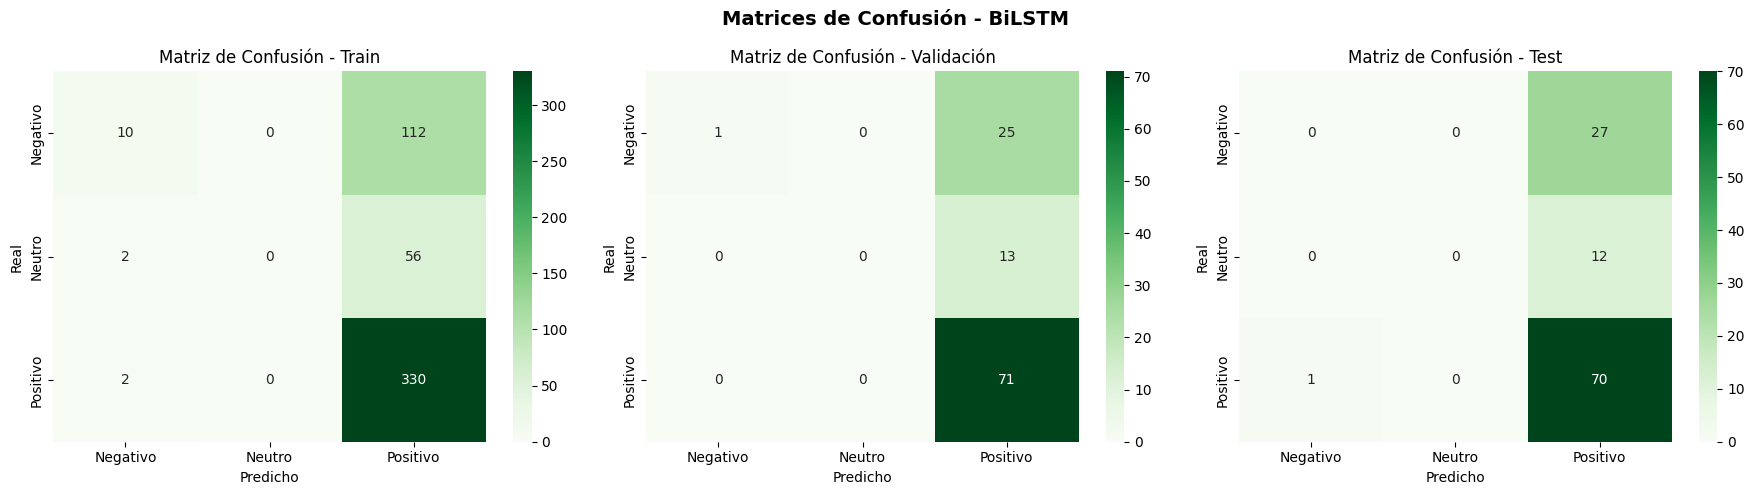

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, res) in zip(axes, [('Train', results_train), ('Validación', results_val), ('Test', results_test)]):
    cm = confusion_matrix(res['labels'], res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Matriz de Confusión - {split_name}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.suptitle('Matrices de Confusión - BiLSTM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9) Curvas ROC por clase (Test)

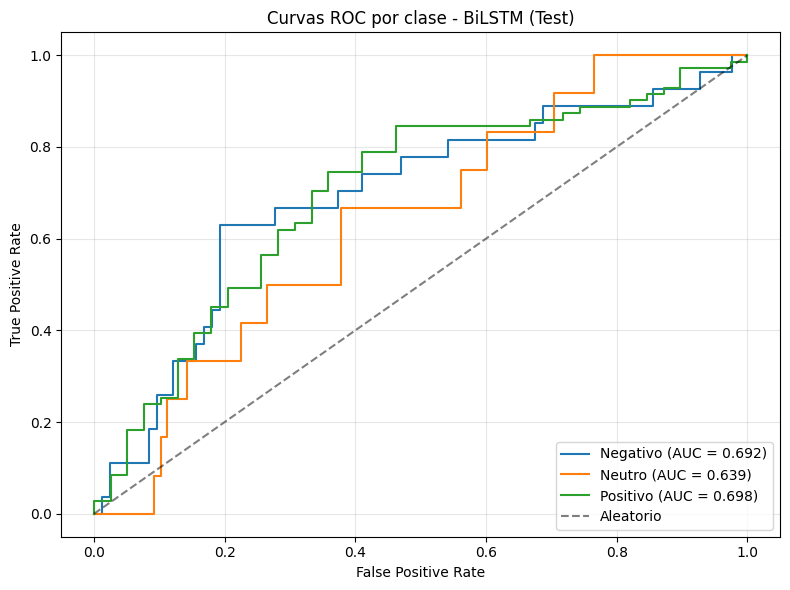

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))

for i, cls_name in enumerate(class_names):
    binary_labels = (results_test['labels'] == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, results_test['probs'][:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{cls_name} (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC por clase - BiLSTM (Test)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10) Resumen de Resultados

In [17]:
summary_df = pd.DataFrame({
    'Split': ['Train', 'Validación', 'Test'],
    'Accuracy': [results_train['acc'], results_val['acc'], results_test['acc']],
    'Precision': [results_train['precision'], results_val['precision'], results_test['precision']],
    'Recall': [results_train['recall'], results_val['recall'], results_test['recall']],
    'F1 (macro)': [results_train['f1_macro'], results_val['f1_macro'], results_test['f1_macro']],
    'F1 (weighted)': [results_train['f1_weighted'], results_val['f1_weighted'], results_test['f1_weighted']],
    'Kappa': [results_train['kappa'], results_val['kappa'], results_test['kappa']],
    'MCC': [results_train['mcc'], results_val['mcc'], results_test['mcc']],
    'AUC-ROC': [results_train['auc_roc'], results_val['auc_roc'], results_test['auc_roc']],
}).round(4)

print('\n=== RESUMEN BiLSTM ===')
print(f'Arquitectura: Embedding({actual_vocab_size}, {EMBED_DIM}) -> BiLSTM({HIDDEN_DIM}, {NUM_LAYERS} capas) -> Dropout({DROPOUT}) -> FC(64) -> ReLU -> FC({NUM_CLASSES})')
print(f'Número de parámetros: {n_params:,}')
print(f'Vocab: {actual_vocab_size} | Seq len: {MAX_SEQ_LEN} | Épocas: {EPOCHS} | LR: {LR} | Batch: {BATCH_SIZE} | Grad clip: {CLIP_GRAD}')
print()
print(summary_df.to_string(index=False))

print(f'| BiLSTM | {n_params:,} | {results_train["acc"]:.4f} | {results_val["acc"]:.4f} | {results_test["acc"]:.4f} | {results_train["f1_macro"]:.4f} | {results_val["f1_macro"]:.4f} | {results_test["f1_macro"]:.4f} |')


=== RESUMEN BiLSTM ===
Arquitectura: Embedding(2032, 32) -> BiLSTM(32, 1 capas) -> Dropout(0.5) -> FC(64) -> ReLU -> FC(3)
Número de parámetros: 86,275
Vocab: 2032 | Seq len: 50 | Épocas: 45 | LR: 0.0005 | Batch: 64 | Grad clip: 1.0

     Split  Accuracy  Precision  Recall  F1 (macro)  F1 (weighted)   Kappa     MCC  AUC-ROC
     Train    0.6641     0.4590  0.3586      0.3141         0.5507  0.0740  0.1630   0.7429
Validación    0.6545     0.5505  0.3462      0.2877         0.5267  0.0358  0.1332   0.6695
      Test    0.6364     0.2141  0.3286      0.2593         0.5020 -0.0152 -0.0568   0.6763
| BiLSTM | 86,275 | 0.6641 | 0.6545 | 0.6364 | 0.3141 | 0.2877 | 0.2593 |


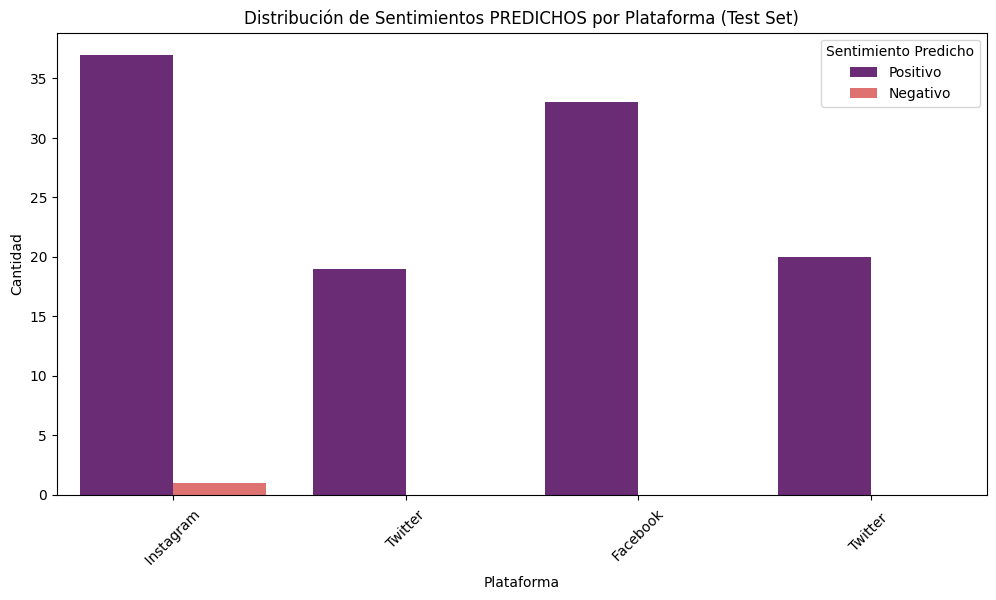

In [18]:
# Visualización: Sentimientos Predichos por Plataforma (Post-entrenamiento)
# Mapear predicciones numéricas a nombres de clases
test_preds_names = [le.classes_[p] for p in results_test['preds']]

# Crear un DataFrame temporal para la visualización
viz_df = (X_test_df if 'X_test_df' in locals() else df_test).copy()
viz_df['Predicted_Sentiment'] = test_preds_names

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.countplot(data=viz_df, x='Platform', hue='Predicted_Sentiment', palette='magma')
plt.title('Distribución de Sentimientos PREDICHOS por Plataforma (Test Set)')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.legend(title='Sentimiento Predicho')
plt.show()